# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [2]:
! git clone https://github.com/vcasadei/MNIST.git

Cloning into 'MNIST'...
remote: Enumerating objects: 10, done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 10 (from 1)
Receiving objects: 100% (10/10), 11.01 MiB | 14.06 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [3]:
!ls MNIST

processed  raw


In [4]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [5]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [6]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

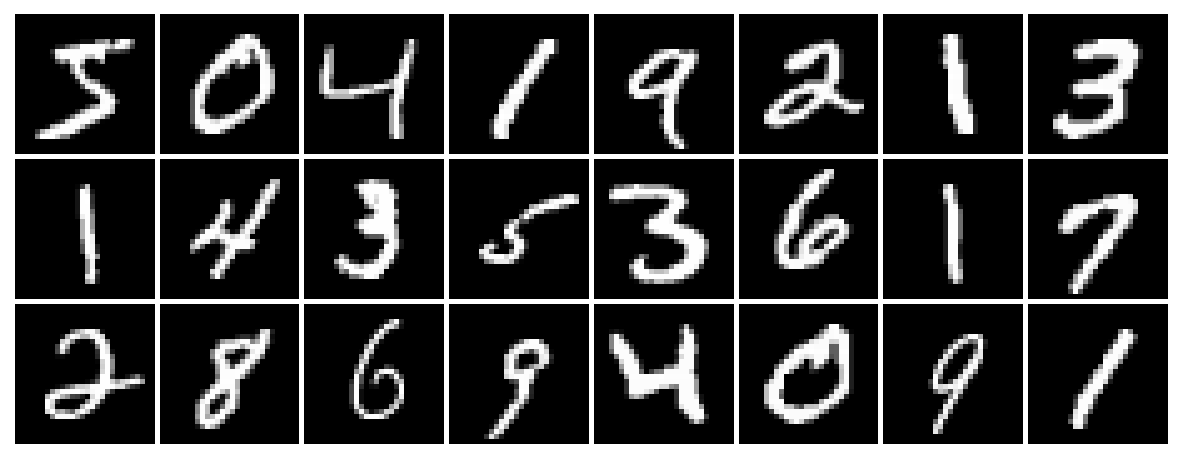

In [7]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


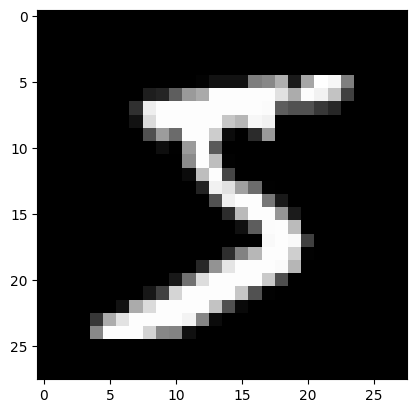

In [8]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [9]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [10]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[ 0.2136, -0.1275, -0.0620,  0.1782, -0.1726, -0.0032, -0.0944, -0.0444,
         -0.0976,  0.0379],
        [-0.0257, -0.3665,  0.0105, -0.0238, -0.0835, -0.0540,  0.4082,  0.1623,
         -0.3032, -0.2136],
        [ 0.2676,  0.0349, -0.0382,  0.1017,  0.1098,  0.1059,  0.2336,  0.0138,
         -0.0201, -0.1421],
        [ 0.2035, -0.0514, -0.0835,  0.0372, -0.0567, -0.0100,  0.0759,  0.0687,
         -0.0779, -0.0949],
        [ 0.4154, -0.2669, -0.2270,  0.1712, -0.0921,  0.0024,  0.1781,  0.1565,
          0.0337,  0.0437]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [11]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [12]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [13]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

Epoch [1/100], Train Loss: 0.2645, Train Acc: 0.9420, Val Loss: 0.3928, Val Acc: 0.8950
Epoch [2/100], Train Loss: 0.2632, Train Acc: 0.9420, Val Loss: 0.3919, Val Acc: 0.8950
Epoch [3/100], Train Loss: 0.2619, Train Acc: 0.9420, Val Loss: 0.3909, Val Acc: 0.8950
Epoch [4/100], Train Loss: 0.2606, Train Acc: 0.9420, Val Loss: 0.3900, Val Acc: 0.8950
Epoch [5/100], Train Loss: 0.2593, Train Acc: 0.9430, Val Loss: 0.3891, Val Acc: 0.8950
Epoch [6/100], Train Loss: 0.2581, Train Acc: 0.9430, Val Loss: 0.3882, Val Acc: 0.8950
Epoch [7/100], Train Loss: 0.2568, Train Acc: 0.9440, Val Loss: 0.3873, Val Acc: 0.8950
Epoch [8/100], Train Loss: 0.2556, Train Acc: 0.9450, Val Loss: 0.3864, Val Acc: 0.8950
Epoch [9/100], Train Loss: 0.2543, Train Acc: 0.9450, Val Loss: 0.3855, Val Acc: 0.9000
Epoch [10/100], Train Loss: 0.2531, Train Acc: 0.9450, Val Loss: 0.3847, Val Acc: 0.9000
Epoch [11/100], Train Loss: 0.2519, Train Acc: 0.9470, Val Loss: 0.3839, Val Acc: 0.9000
Epoch [12/100], Train Loss: 0.

In [14]:
print('Final loss:', loss.item())

Final loss: 0.2658654451370239


### Visualizando gráfico de perda durante o treinamento

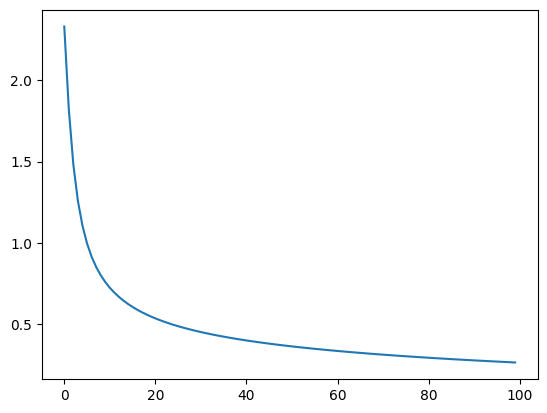

In [15]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

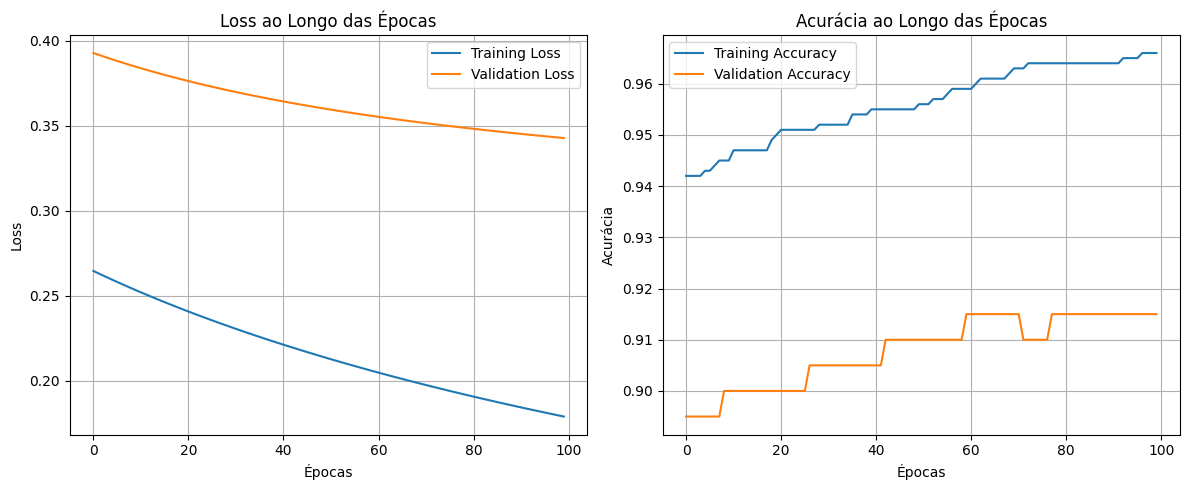

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [17]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.966


### Matriz de confusão com dados de treinamento e teste

In [18]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,1,0
2,0,0,92,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,103,1,0,1,0,2
5,0,2,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,1,2,0,0,0,0,0,85,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


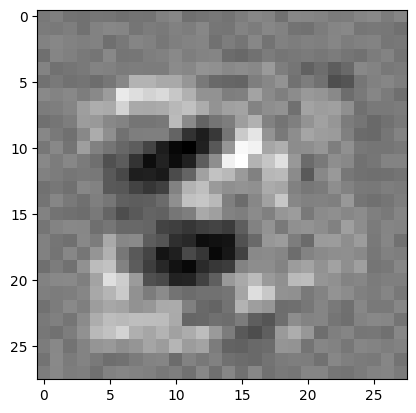

In [19]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

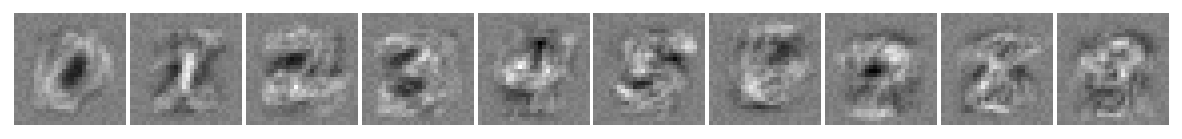

In [20]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

In [22]:
losses = []
zs = []

for i in range(epochs):
    inputs = Variable(x_train.view(-1, 28 * 28))
    outputs = model(inputs)

    zs.append(outputs[1].detach().numpy())

    loss = criterion(outputs, Variable(y_train))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
          .format(i+1, epochs, loss.data, accuracy))

Epoch[1/100], loss: 0.134063, acc: 0.977000
Epoch[2/100], loss: 0.133724, acc: 0.978000
Epoch[3/100], loss: 0.133387, acc: 0.978000
Epoch[4/100], loss: 0.133051, acc: 0.978000
Epoch[5/100], loss: 0.132716, acc: 0.978000
Epoch[6/100], loss: 0.132383, acc: 0.978000
Epoch[7/100], loss: 0.132052, acc: 0.978000
Epoch[8/100], loss: 0.131722, acc: 0.978000
Epoch[9/100], loss: 0.131393, acc: 0.978000
Epoch[10/100], loss: 0.131066, acc: 0.978000
Epoch[11/100], loss: 0.130741, acc: 0.978000
Epoch[12/100], loss: 0.130417, acc: 0.978000
Epoch[13/100], loss: 0.130094, acc: 0.978000
Epoch[14/100], loss: 0.129773, acc: 0.978000
Epoch[15/100], loss: 0.129453, acc: 0.978000
Epoch[16/100], loss: 0.129135, acc: 0.978000
Epoch[17/100], loss: 0.128818, acc: 0.978000
Epoch[18/100], loss: 0.128502, acc: 0.978000
Epoch[19/100], loss: 0.128188, acc: 0.978000
Epoch[20/100], loss: 0.127875, acc: 0.978000
Epoch[21/100], loss: 0.127564, acc: 0.978000
Epoch[22/100], loss: 0.127254, acc: 0.978000
Epoch[23/100], loss

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

Epoch[1/100], loss: 0.106442, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


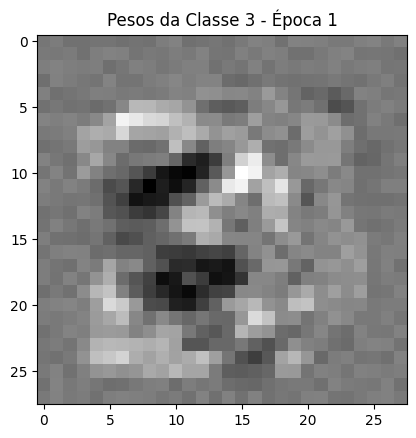

Epoch[2/100], loss: 0.106218, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


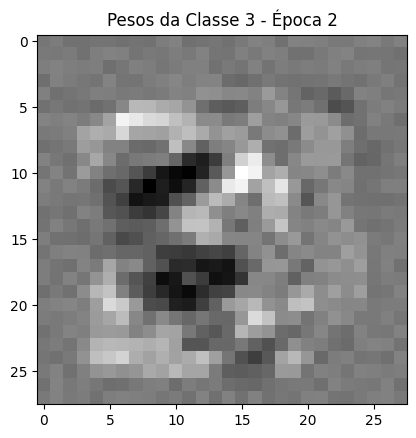

Epoch[3/100], loss: 0.105995, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


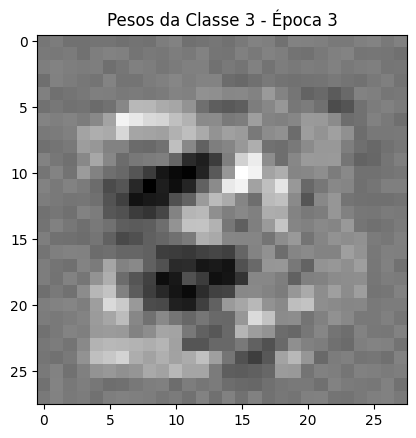

Epoch[4/100], loss: 0.105773, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


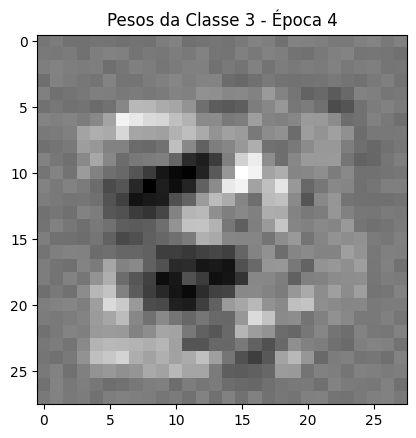

Epoch[5/100], loss: 0.105552, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


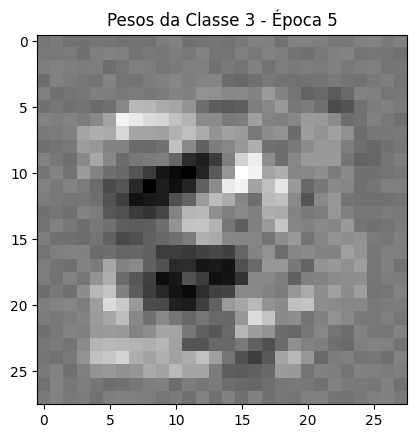

Epoch[6/100], loss: 0.105331, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


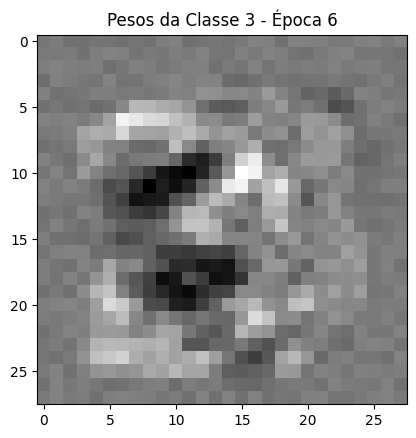

Epoch[7/100], loss: 0.105112, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


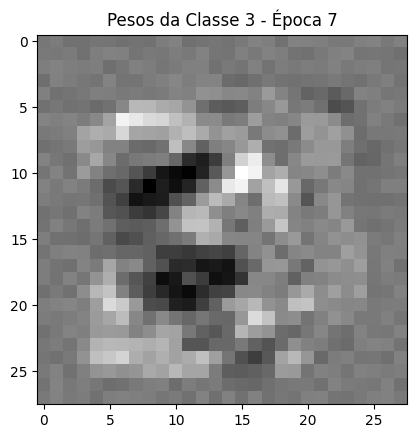

Epoch[8/100], loss: 0.104893, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


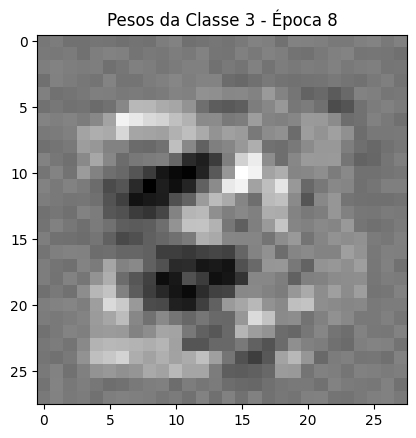

Epoch[9/100], loss: 0.104675, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


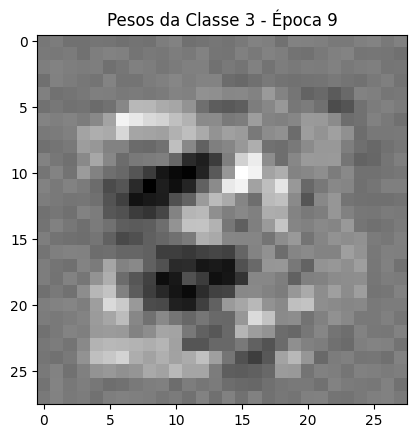

Epoch[10/100], loss: 0.104458, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


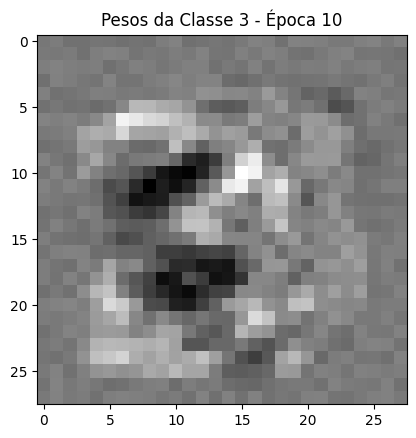

Epoch[11/100], loss: 0.104242, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


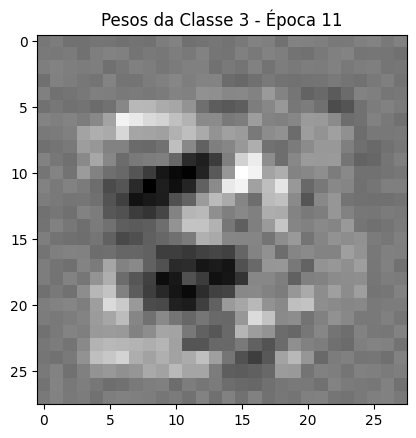

Epoch[12/100], loss: 0.104027, acc: 0.992000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


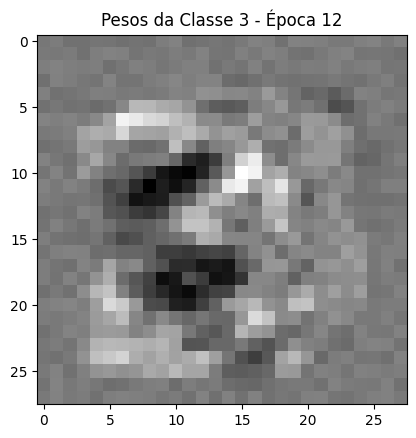

Epoch[13/100], loss: 0.103812, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


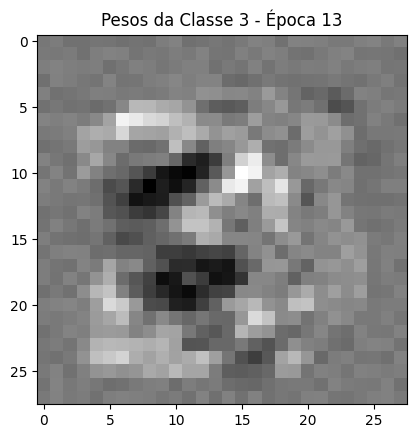

Epoch[14/100], loss: 0.103598, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


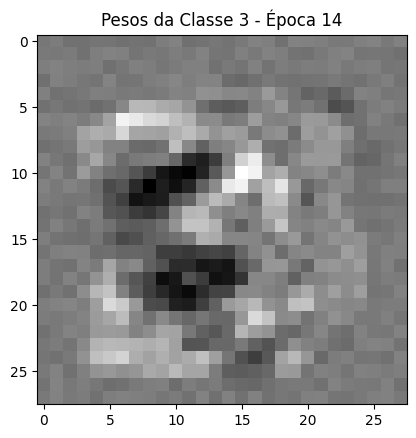

Epoch[15/100], loss: 0.103385, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


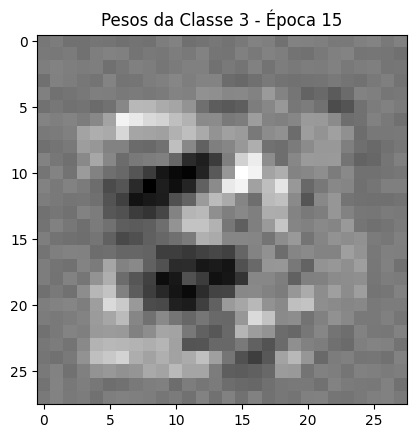

Epoch[16/100], loss: 0.103173, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


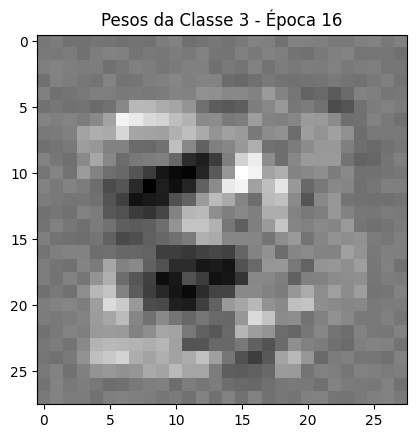

Epoch[17/100], loss: 0.102961, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


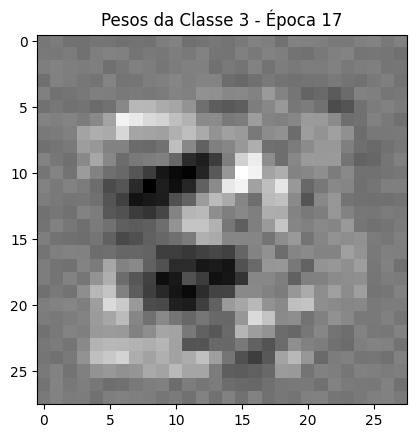

Epoch[18/100], loss: 0.102751, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


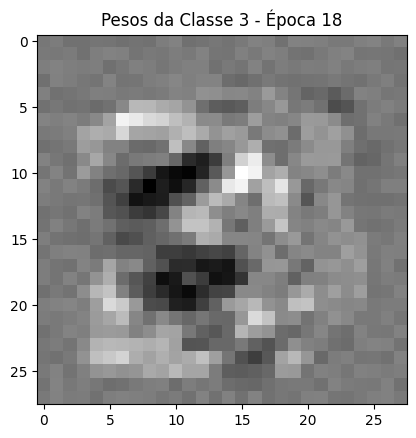

Epoch[19/100], loss: 0.102541, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


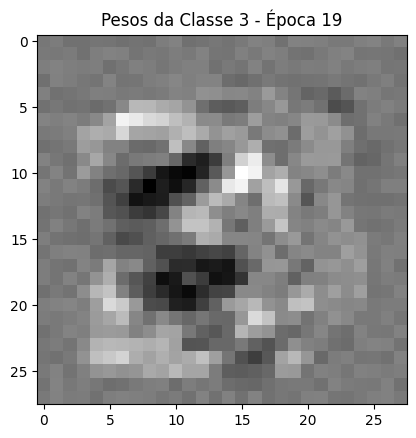

Epoch[20/100], loss: 0.102332, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


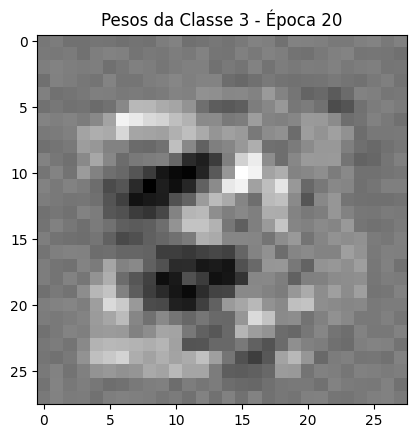

Epoch[21/100], loss: 0.102123, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


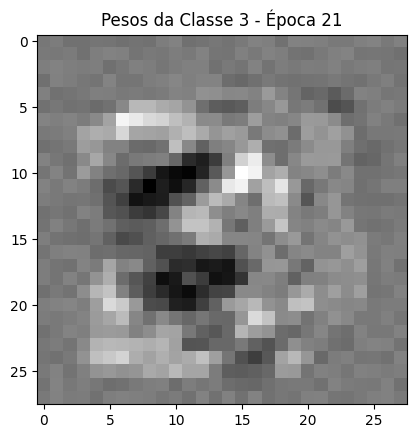

Epoch[22/100], loss: 0.101916, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


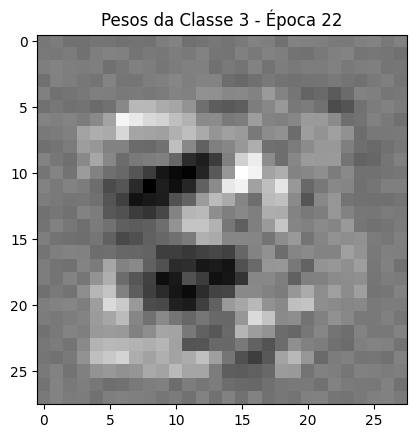

Epoch[23/100], loss: 0.101709, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


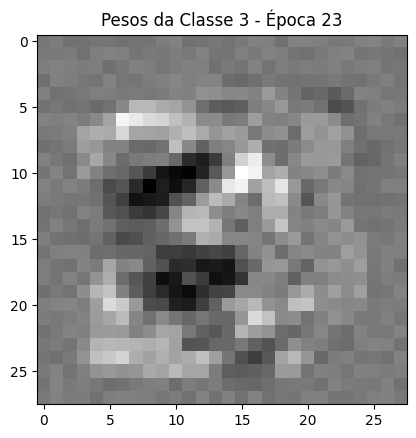

Epoch[24/100], loss: 0.101503, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


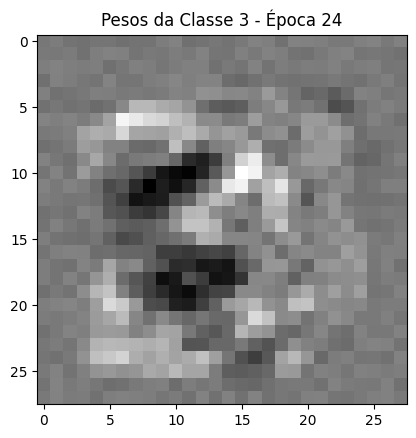

Epoch[25/100], loss: 0.101298, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


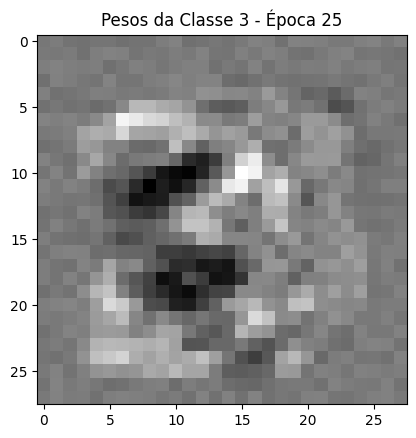

Epoch[26/100], loss: 0.101093, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


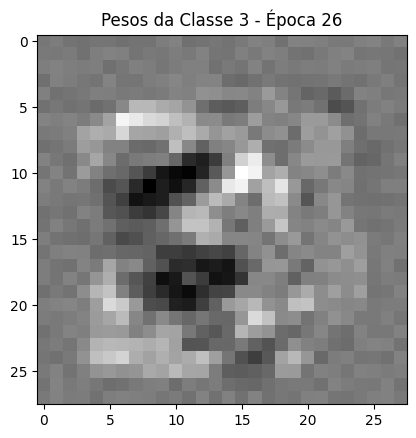

Epoch[27/100], loss: 0.100889, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


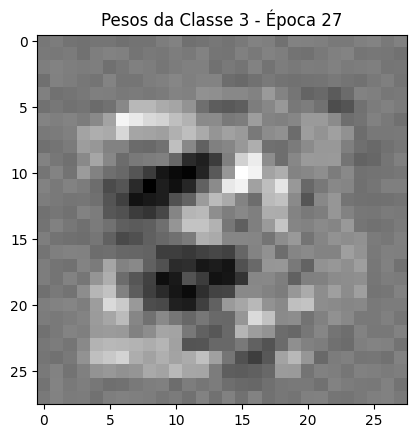

Epoch[28/100], loss: 0.100686, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


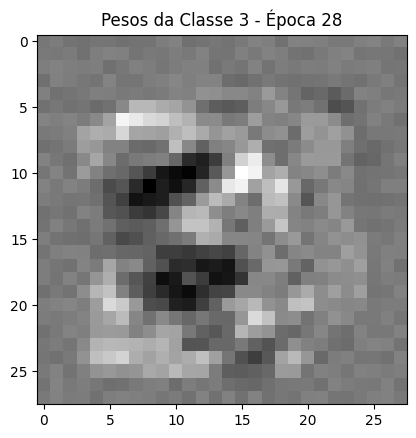

Epoch[29/100], loss: 0.100484, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


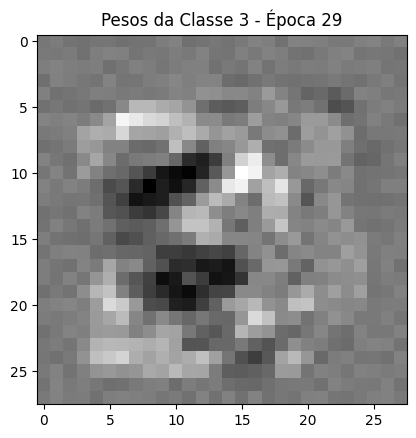

Epoch[30/100], loss: 0.100282, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


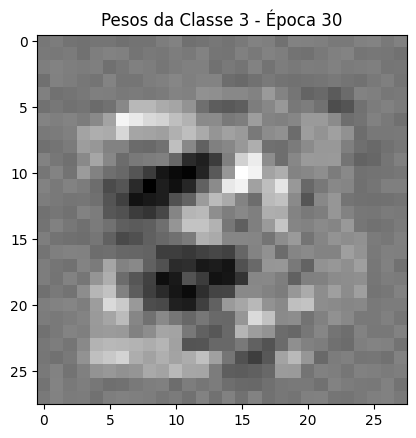

Epoch[31/100], loss: 0.100081, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


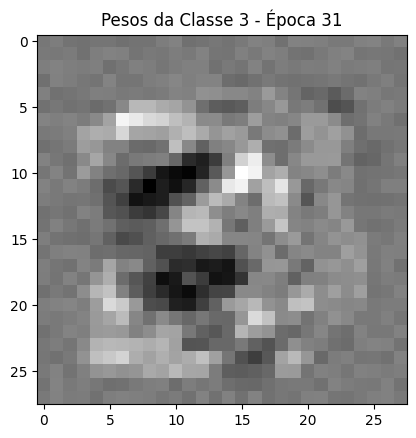

Epoch[32/100], loss: 0.099881, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


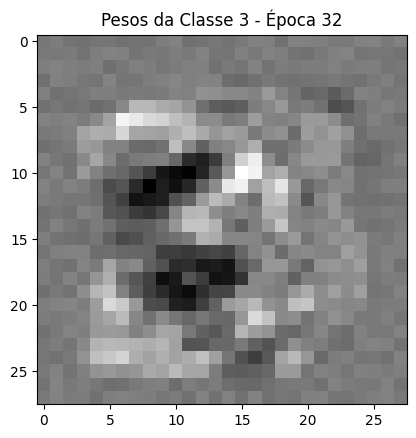

Epoch[33/100], loss: 0.099682, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


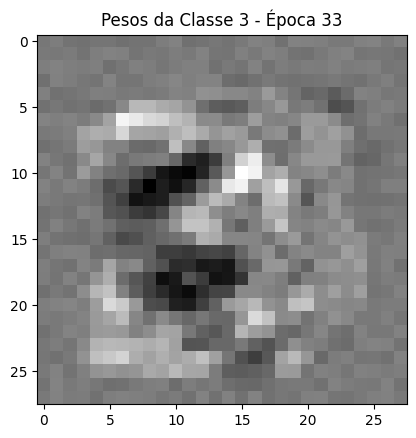

Epoch[34/100], loss: 0.099483, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


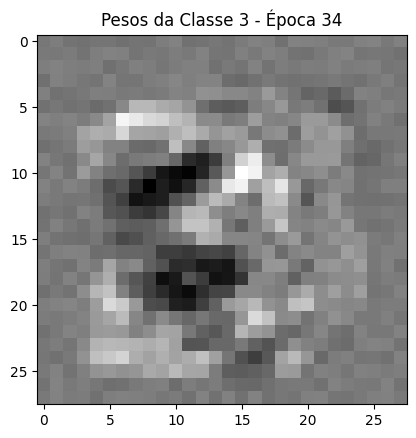

Epoch[35/100], loss: 0.099285, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


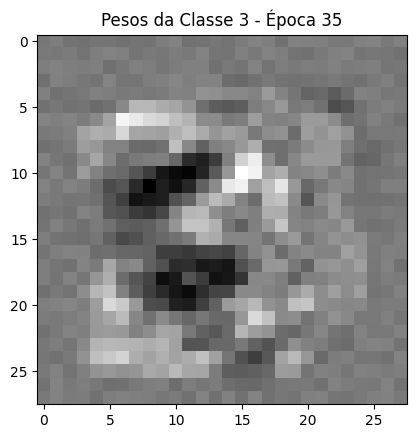

Epoch[36/100], loss: 0.099088, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


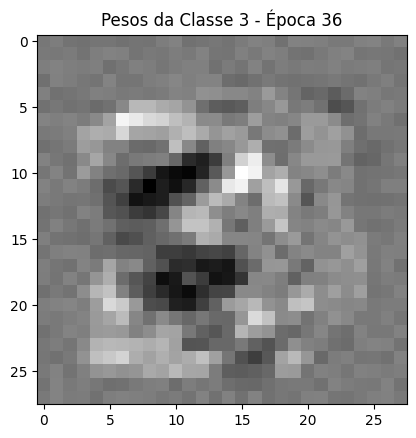

Epoch[37/100], loss: 0.098891, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


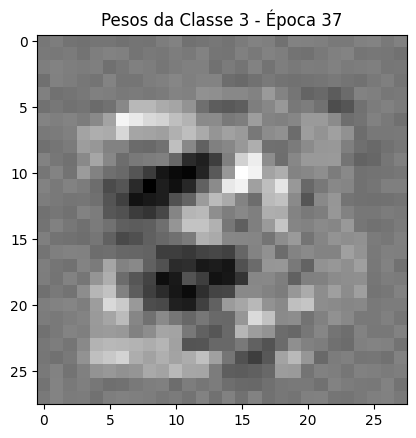

Epoch[38/100], loss: 0.098695, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


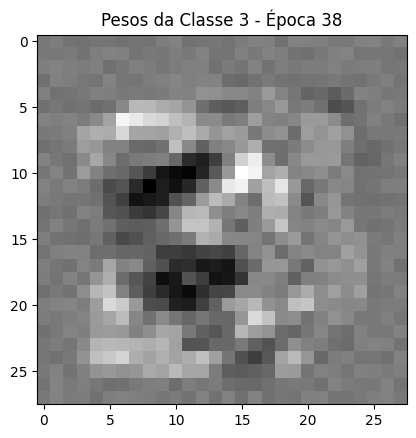

Epoch[39/100], loss: 0.098500, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


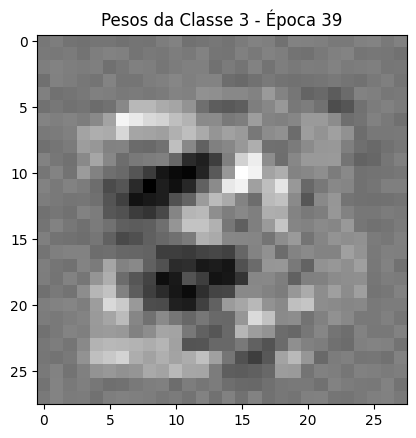

Epoch[40/100], loss: 0.098306, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


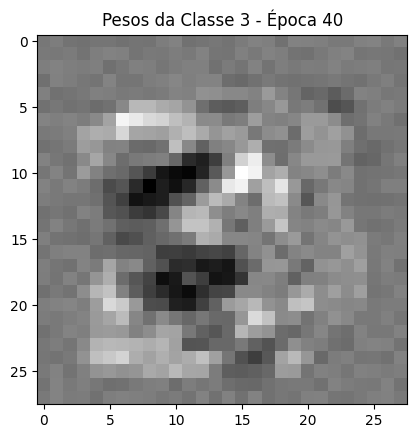

Epoch[41/100], loss: 0.098112, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


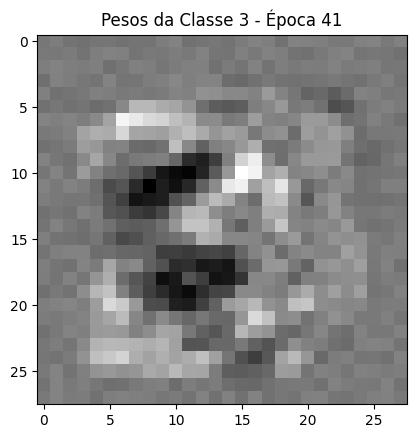

Epoch[42/100], loss: 0.097919, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


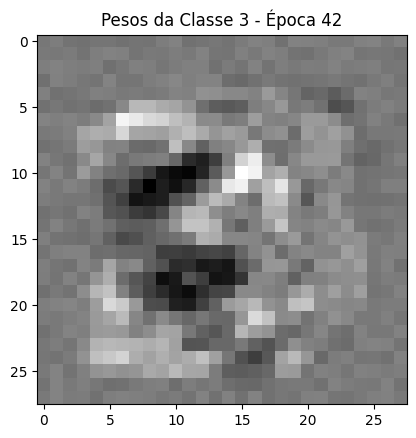

Epoch[43/100], loss: 0.097727, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


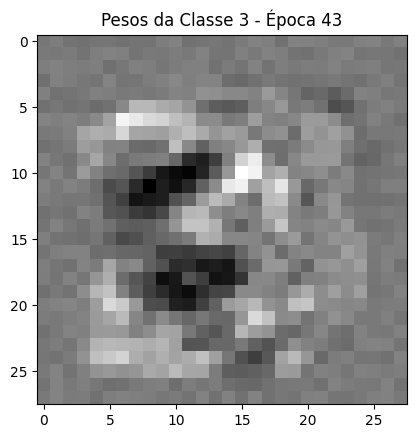

Epoch[44/100], loss: 0.097535, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


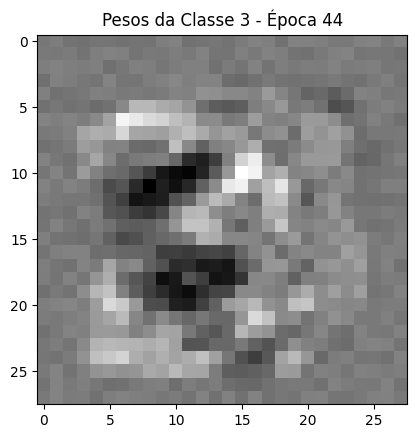

Epoch[45/100], loss: 0.097344, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


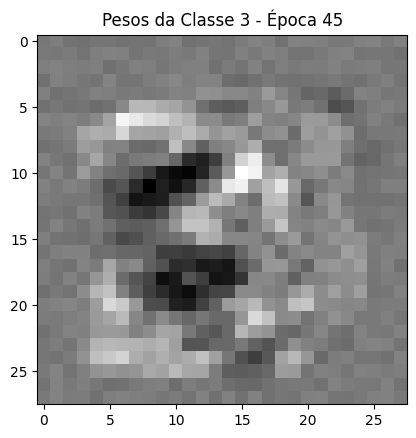

Epoch[46/100], loss: 0.097154, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


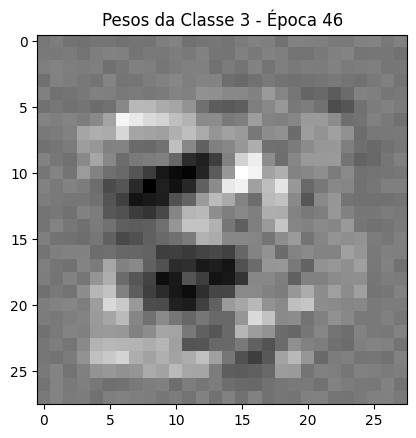

Epoch[47/100], loss: 0.096964, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


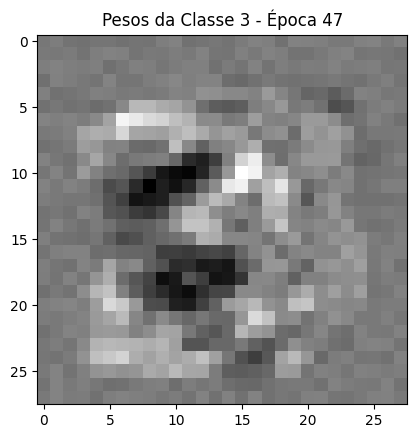

Epoch[48/100], loss: 0.096775, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


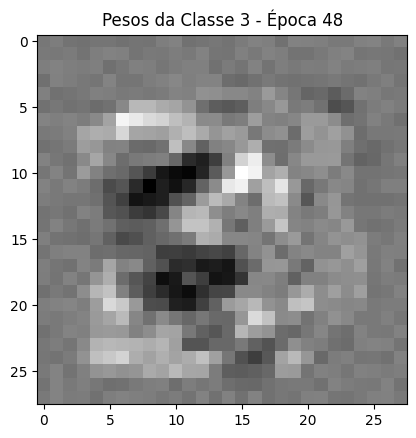

Epoch[49/100], loss: 0.096587, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


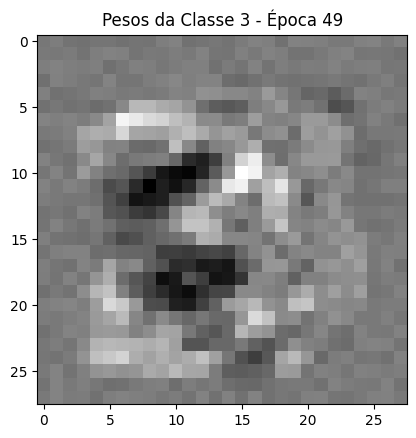

Epoch[50/100], loss: 0.096399, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


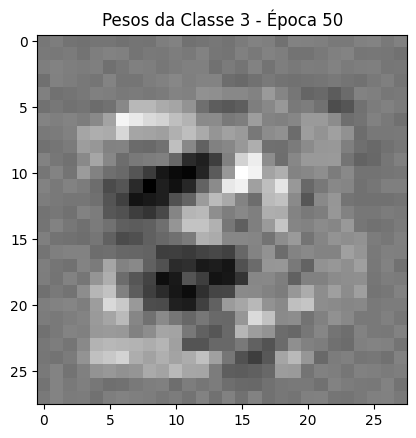

Epoch[51/100], loss: 0.096212, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


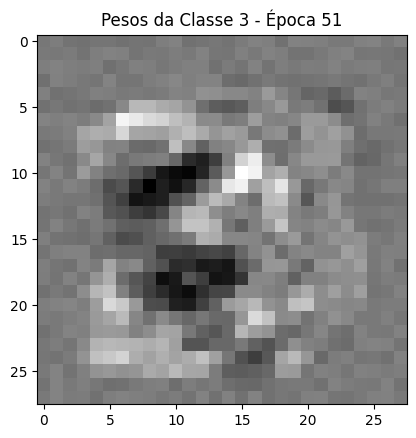

Epoch[52/100], loss: 0.096026, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


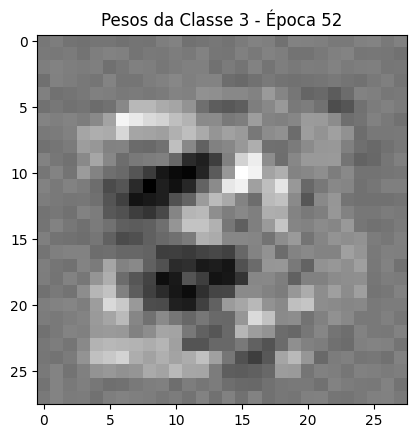

Epoch[53/100], loss: 0.095840, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


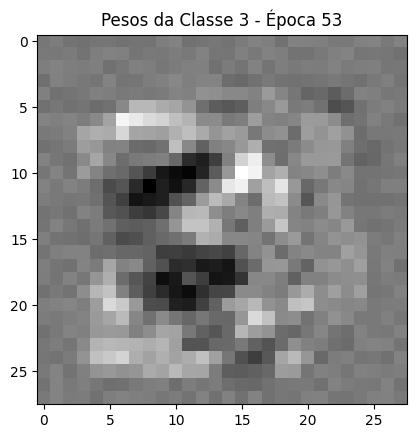

Epoch[54/100], loss: 0.095655, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


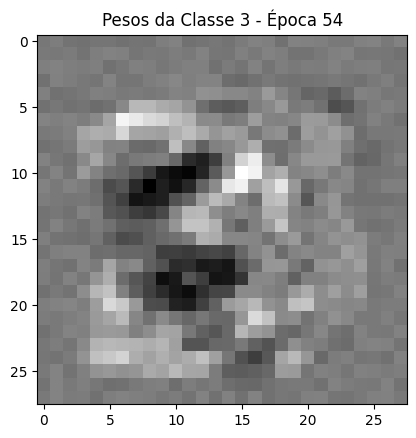

Epoch[55/100], loss: 0.095471, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


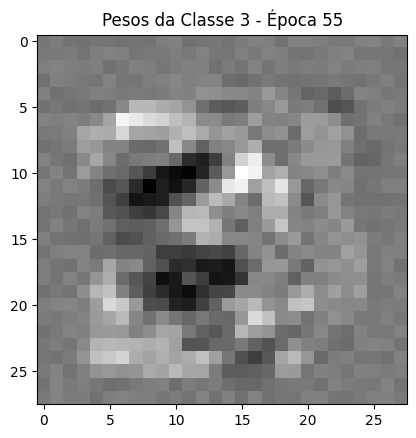

Epoch[56/100], loss: 0.095287, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


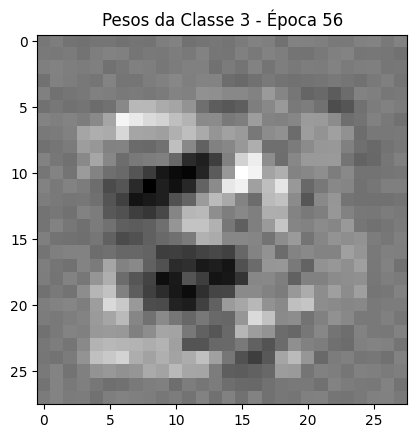

Epoch[57/100], loss: 0.095104, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


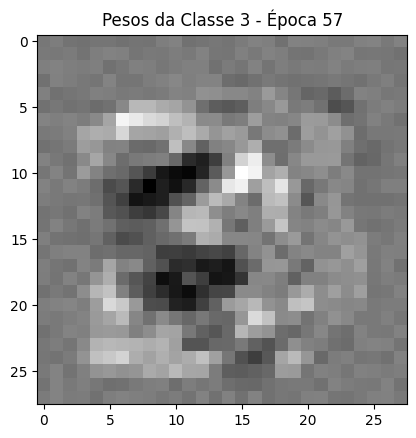

Epoch[58/100], loss: 0.094921, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


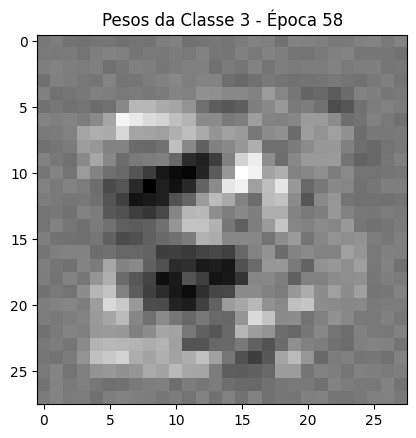

Epoch[59/100], loss: 0.094740, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


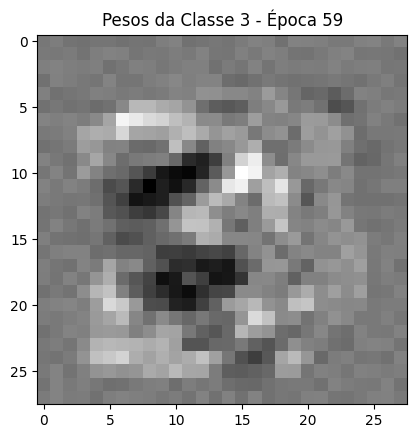

Epoch[60/100], loss: 0.094558, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


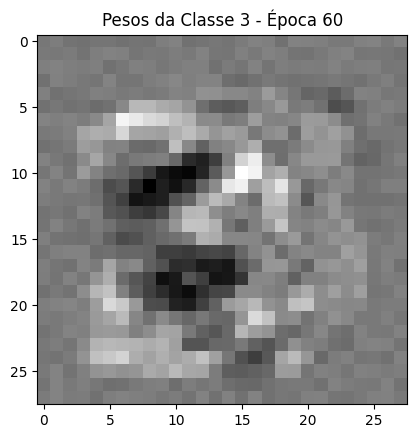

Epoch[61/100], loss: 0.094378, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


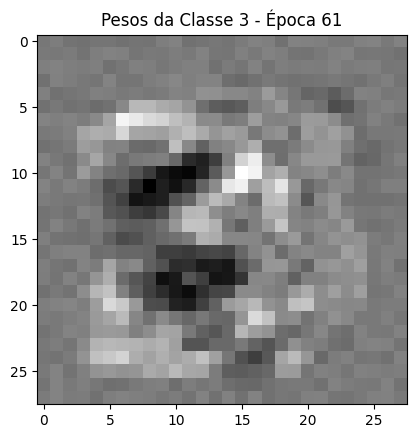

Epoch[62/100], loss: 0.094198, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


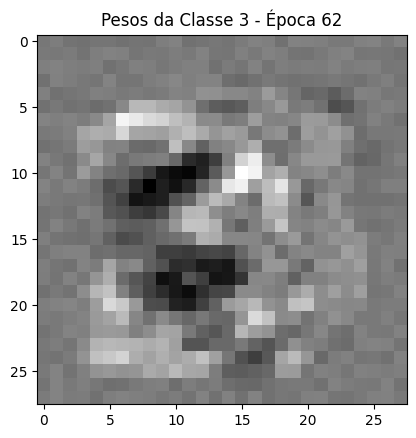

Epoch[63/100], loss: 0.094019, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


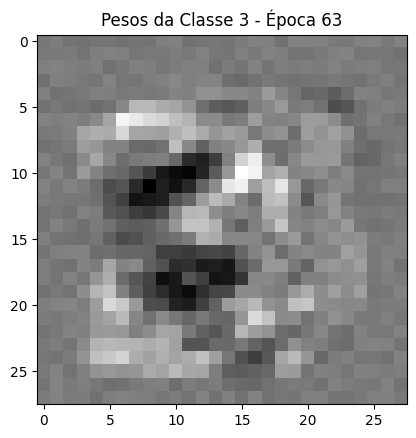

Epoch[64/100], loss: 0.093840, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


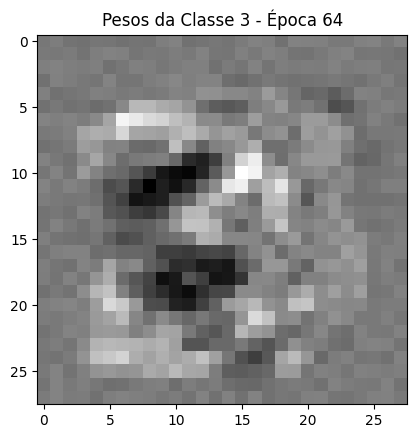

Epoch[65/100], loss: 0.093662, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


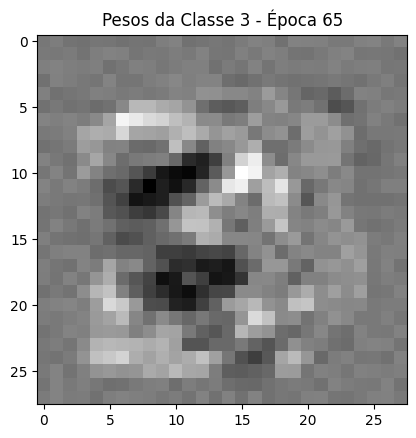

Epoch[66/100], loss: 0.093485, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


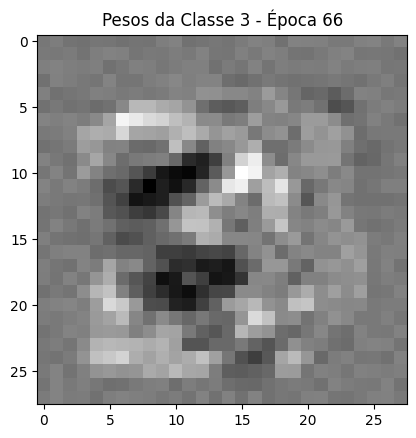

Epoch[67/100], loss: 0.093308, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


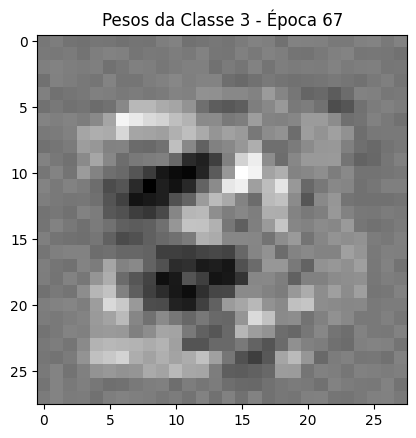

Epoch[68/100], loss: 0.093131, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


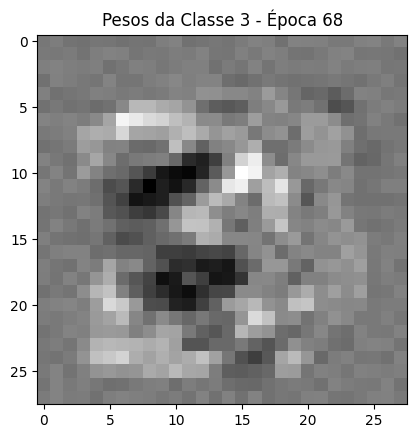

Epoch[69/100], loss: 0.092956, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


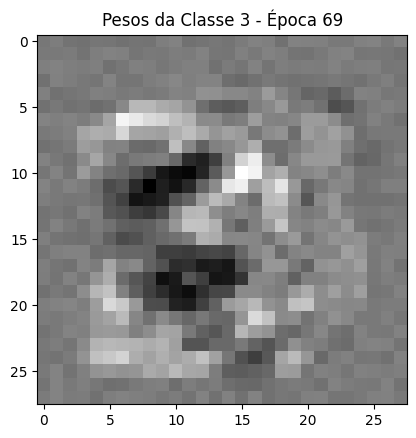

Epoch[70/100], loss: 0.092781, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


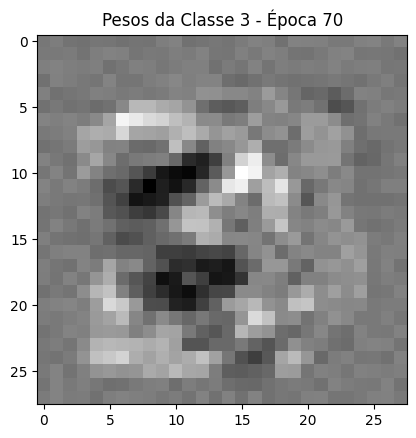

Epoch[71/100], loss: 0.092606, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


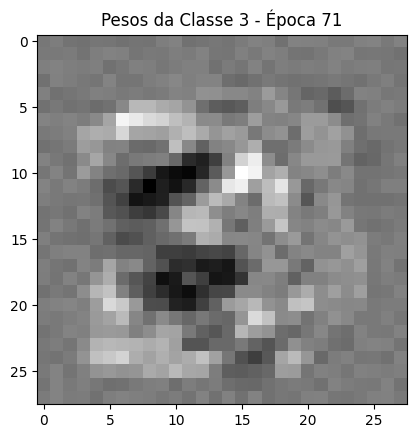

Epoch[72/100], loss: 0.092433, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


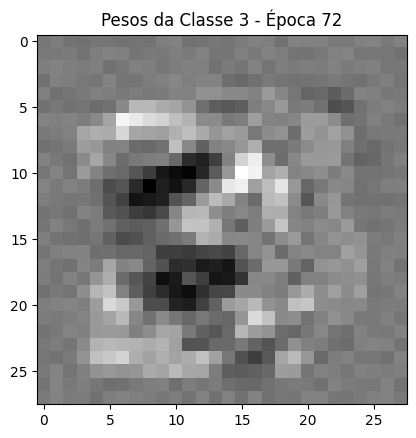

Epoch[73/100], loss: 0.092259, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


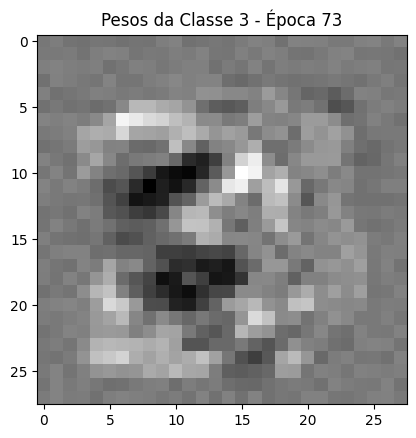

Epoch[74/100], loss: 0.092087, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


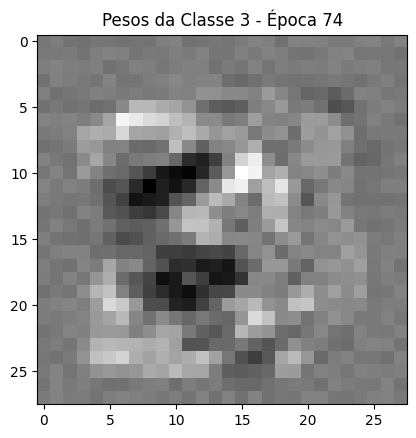

Epoch[75/100], loss: 0.091915, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


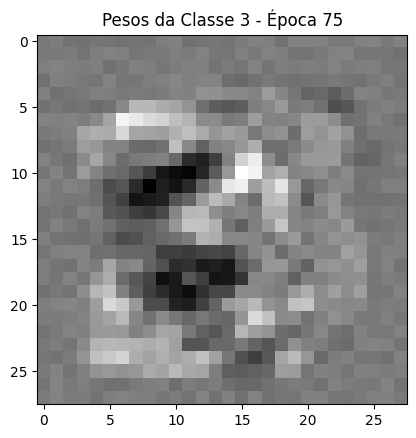

Epoch[76/100], loss: 0.091743, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


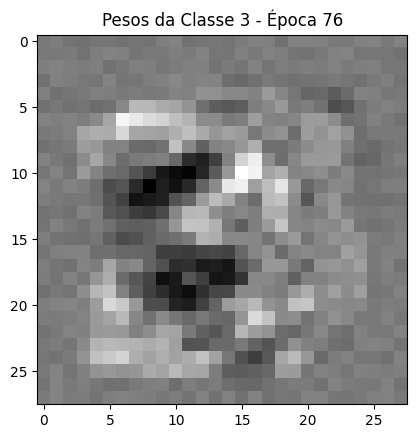

Epoch[77/100], loss: 0.091572, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


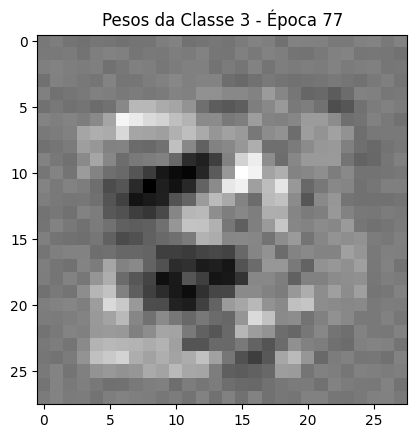

Epoch[78/100], loss: 0.091402, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


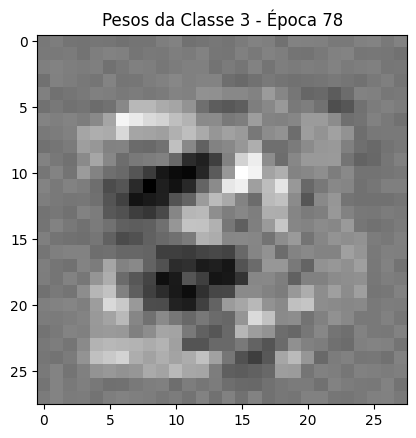

Epoch[79/100], loss: 0.091232, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


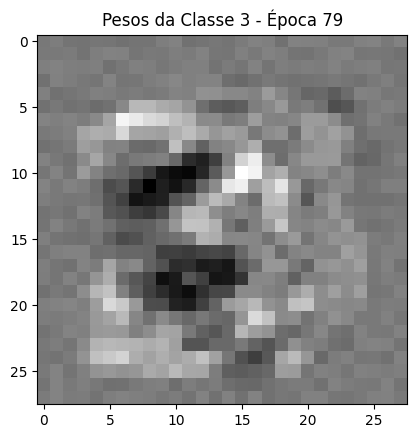

Epoch[80/100], loss: 0.091063, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


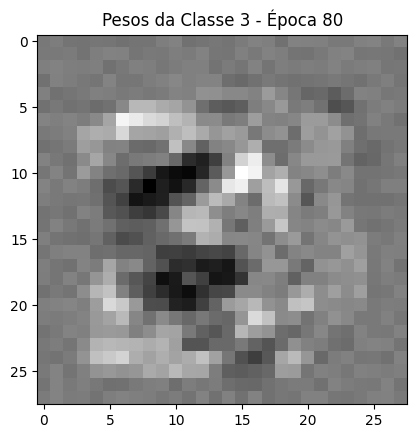

Epoch[81/100], loss: 0.090895, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


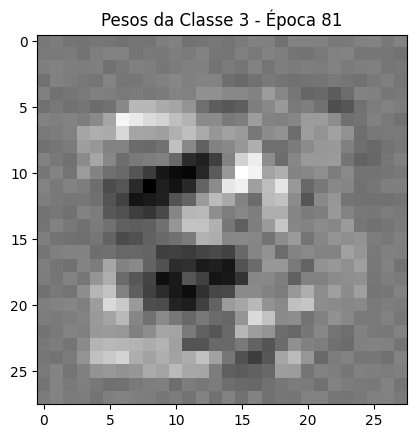

Epoch[82/100], loss: 0.090727, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


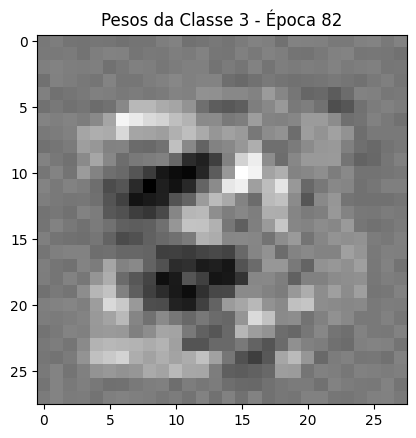

Epoch[83/100], loss: 0.090559, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


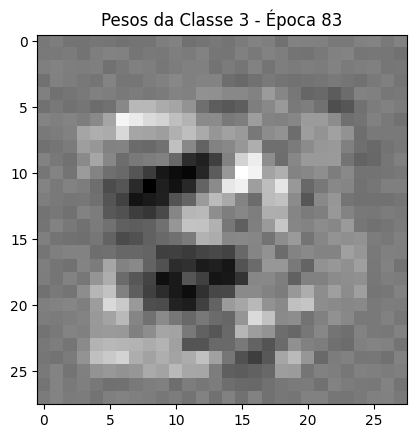

Epoch[84/100], loss: 0.090393, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


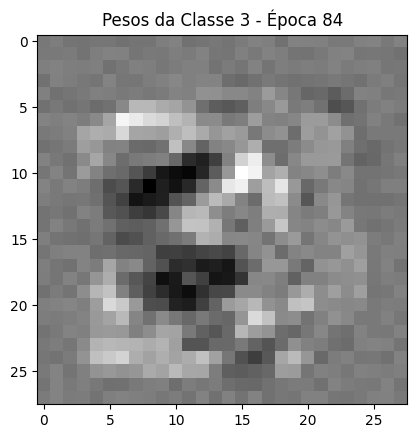

Epoch[85/100], loss: 0.090226, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


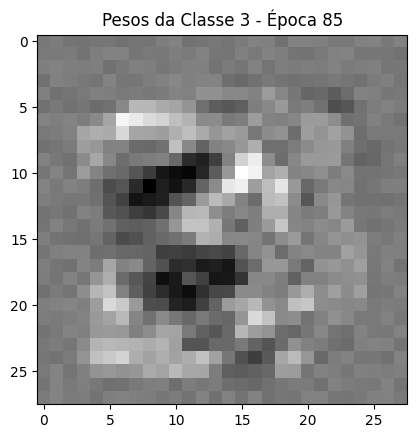

Epoch[86/100], loss: 0.090060, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


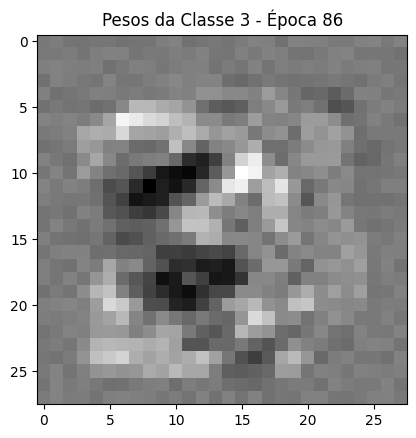

Epoch[87/100], loss: 0.089895, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


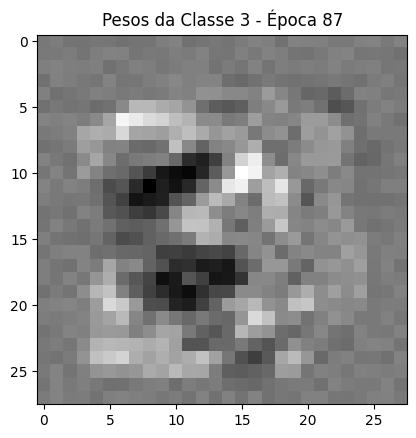

Epoch[88/100], loss: 0.089731, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


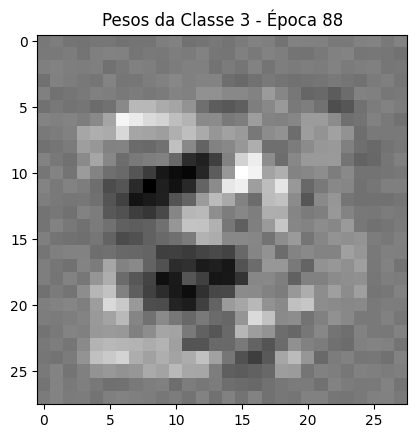

Epoch[89/100], loss: 0.089567, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


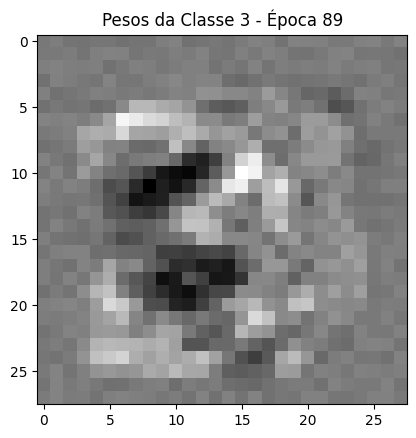

Epoch[90/100], loss: 0.089403, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


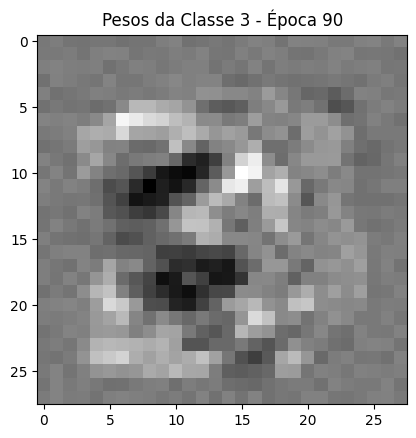

Epoch[91/100], loss: 0.089240, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


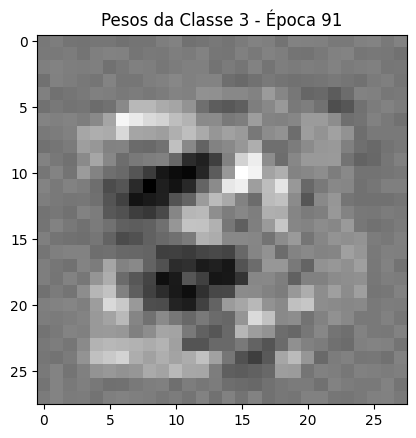

Epoch[92/100], loss: 0.089078, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


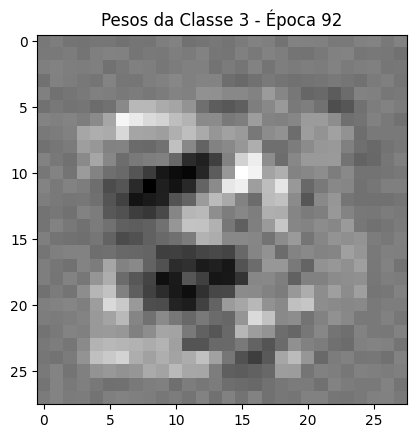

Epoch[93/100], loss: 0.088916, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


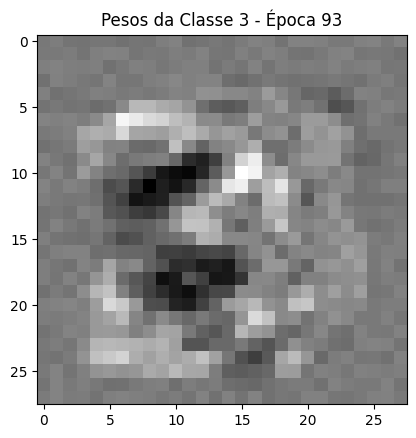

Epoch[94/100], loss: 0.088754, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


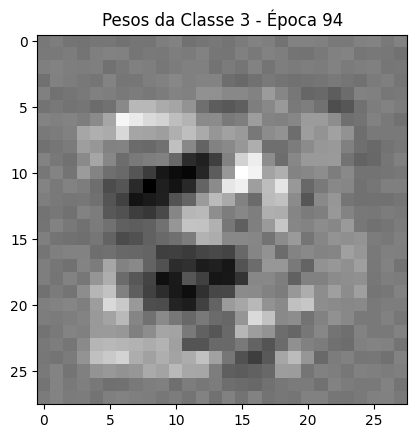

Epoch[95/100], loss: 0.088594, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


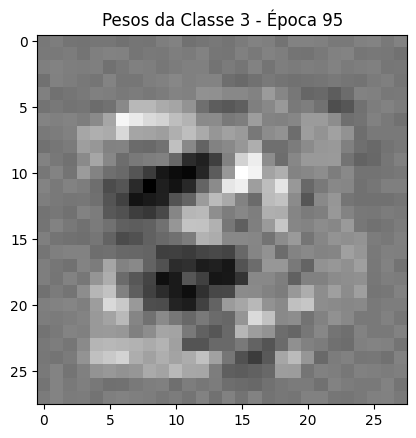

Epoch[96/100], loss: 0.088433, acc: 0.996000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


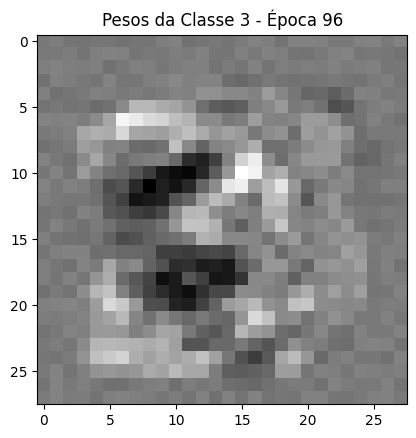

Epoch[97/100], loss: 0.088274, acc: 0.996000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


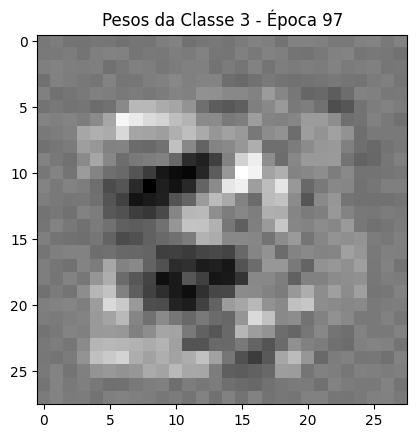

Epoch[98/100], loss: 0.088114, acc: 0.996000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


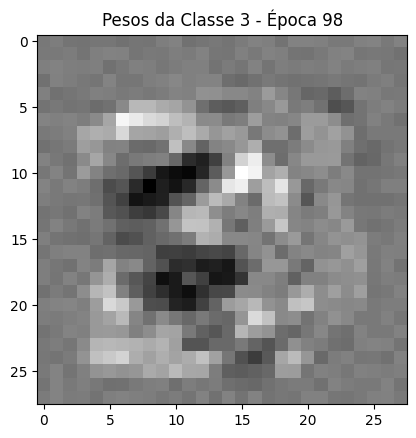

Epoch[99/100], loss: 0.087956, acc: 0.996000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


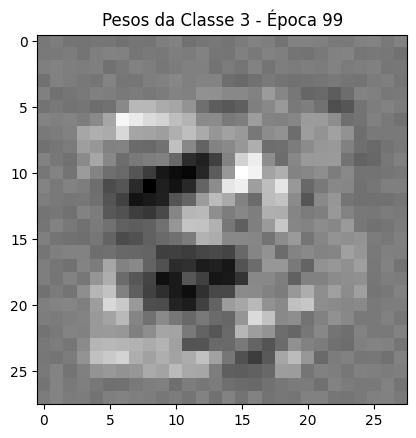

Epoch[100/100], loss: 0.087798, acc: 0.996000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


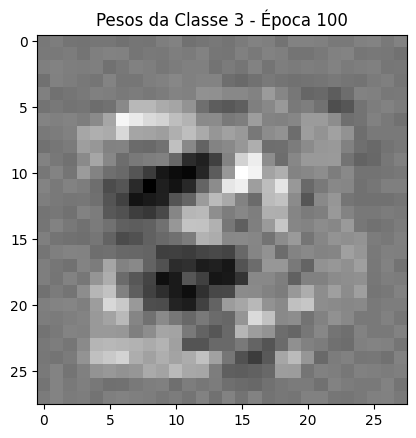

In [23]:
import numpy as np
import torch
import matplotlib.pyplot as plt

losses = []
zs = []

for i in range(epochs):
    inputs = x_train.view(-1, 28 * 28)

    outputs = model(inputs)

    zs.append(outputs[1].detach().cpu().numpy())

    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    accuracy = (predicts == y_train).float().mean().item()

    print(f"Epoch[{i+1}/{epochs}], loss: {loss.item():.6f}, acc: {accuracy:.6f}")

    weights = model.weight.data
    bias = model.bias.data

    print('weights:', weights.shape)
    print('bias:   ', bias.shape)

    plt.imshow(weights[3, :].cpu().numpy().reshape((28, 28)), cmap='gray')
    plt.title(f"Pesos da Classe 3 - Época {i+1}")
    plt.show()

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede?
Resposta: [1, 784]
2. Qual é o shape da saída da rede?
Resposta: [1, 10]
3. Qual é o número total de parâmetros da rede, incluindo o bias?
Resposta: 7840 parâmentros + 10 bias = 7850 parâmentros

# Aprendizados


Neste experimento, o dataset MNIST foi classificado por meio de uma camada nn.Linear(784, 10) com 7.850 parâmetros, alimentada por imagens normalizadas e vetorizadas em 784 atributos através do método .view(-1, 28*28). O processo de generalização foi monitorado com um conjunto de validação sob o comando torch.no_grad(), enquanto a evolução do aprendizado pôde ser interpretada visualmente ao remodelar os pesos de volta para o formato 28×28, revelando graficamente como a rede ajusta suas conexões a cada época para destacar os pixels mais importantes de cada dígito.